# Sensor Modality and Walkability Dimension Co-occurrence Analysis

In [1]:
import json
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import silhouette_score

pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
plt.rcParams.update({"axes.labelsize": 14})
plt.rcParams.update({"xtick.labelsize": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

MATTE_COLORS = {
    "blue": "#4f9dc4",
    "red": "#e9785a",
    "teal": "#8ed165",
    "navy": "#3b3d3f",
    "gold": "#f2d156",
    "text": "#333333",
    "pink": "#d97eb8",
    "purple": "#9478d5",
    "grid": "#dddddd",
    "background": "#f7f7f7",
}

def plot_label_combinations(memberships, title, top_n=15):
    """Combination-frequency plot (bar chart of counts + membership matrix),
    for showing how many articles share each exact set of labels."""
    combo_counts = Counter(tuple(sorted(m)) for m in memberships if len(m) > 0)
    top_combos = combo_counts.most_common(top_n)
    categories = sorted({c for combo, _ in top_combos for c in combo})

    n_combos = len(top_combos)
    n_cats = len(categories)
    fig = plt.figure(figsize=(max(9, n_combos * 0.6), 3.5 + n_cats * 0.35))
    gs = fig.add_gridspec(2, 1, height_ratios=[2.2, n_cats * 0.35], hspace=0.05)
    ax_bar = fig.add_subplot(gs[0])
    ax_dots = fig.add_subplot(gs[1], sharex=ax_bar)

    counts = [c for _, c in top_combos]
    ax_bar.bar(range(n_combos), counts, color=MATTE_COLORS["blue"], edgecolor=MATTE_COLORS["navy"])
    for i, c in enumerate(counts):
        ax_bar.text(i, c + max(counts) * 0.01, str(c), ha="center", va="bottom", fontsize=9)
    ax_bar.set_ylabel("Number of Articles")
    ax_bar.set_xticks([])
    ax_bar.set_title(title)
    ax_bar.spines[["top", "right"]].set_visible(False)

    for i, (combo, _) in enumerate(top_combos):
        for j, cat in enumerate(categories):
            filled = cat in combo
            ax_dots.plot(i, j, "o", color=MATTE_COLORS["navy"] if filled else MATTE_COLORS["grid"], markersize=8)
        member_idx = [categories.index(c) for c in combo]
        if len(member_idx) > 1:
            ax_dots.plot([i] * len(member_idx), member_idx, color=MATTE_COLORS["navy"], linewidth=1.5, zorder=0)

    ax_dots.set_yticks(range(n_cats))
    ax_dots.set_yticklabels(categories)
    ax_dots.set_xlim(-0.5, n_combos - 0.5)
    ax_dots.set_ylim(-0.5, n_cats - 0.5)
    ax_dots.invert_yaxis()
    ax_dots.set_xticks([])
    for spine in ax_dots.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

# 1. Load Dataset

In [2]:
df = pd.read_json("../data/06_4_dimensions_with_sensor_types.json")
df["macro_dimensions"] = df["macro_dimensions"].apply(lambda x: x if isinstance(x, list) else [])
df["macro_sensor_types"] = df["macro_sensor_types"].apply(lambda x: x if isinstance(x, list) else [])

print(f"Loaded {len(df)} articles")
print(f"Articles with at least one sensor category: {(df['macro_sensor_types'].str.len() > 0).sum()}")

Loaded 737 articles
Articles with at least one sensor category: 366


# 2. Documents per Year

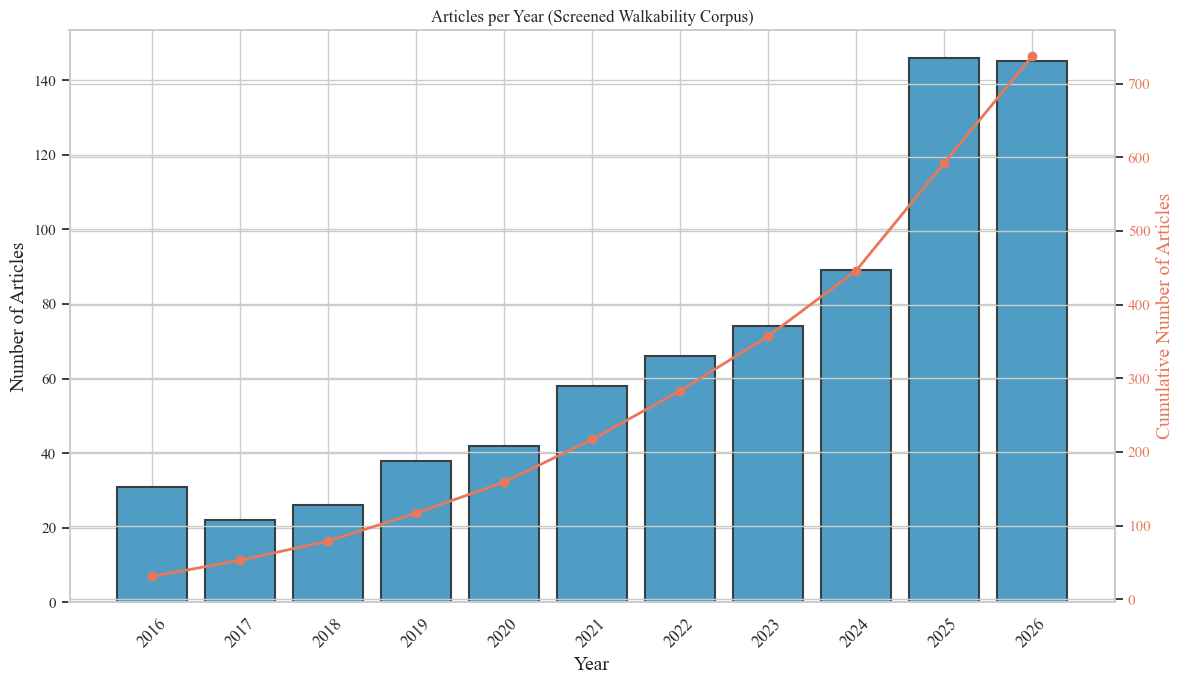

In [3]:
if "publication_date" in df.columns:
    year_counts = df["publication_date"].value_counts().sort_index()
    df_years = year_counts.reset_index()
    df_years.columns = ["Year", "Count"]
    df_years["Cumulative"] = df_years["Count"].cumsum()

    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax2 = ax1.twinx()

    ax1.bar(df_years["Year"].astype(str), df_years["Count"],
            color=MATTE_COLORS["blue"], edgecolor=MATTE_COLORS["navy"], linewidth=1.5)
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Number of Articles")
    ax1.tick_params(axis="x", rotation=45)

    ax2.plot(df_years["Year"].astype(str), df_years["Cumulative"],
              color=MATTE_COLORS["red"], marker="o", linewidth=2)
    ax2.set_ylabel("Cumulative Number of Articles", color=MATTE_COLORS["red"])
    ax2.tick_params(axis="y", labelcolor=MATTE_COLORS["red"])

    ax1.set_title("Articles per Year (Screened Walkability Corpus)")
    plt.tight_layout()
    plt.show()
else:
    print("Column \'publication_date\' not found in the dataset -- skipping this chart.")

# 3. Articles per Document Type

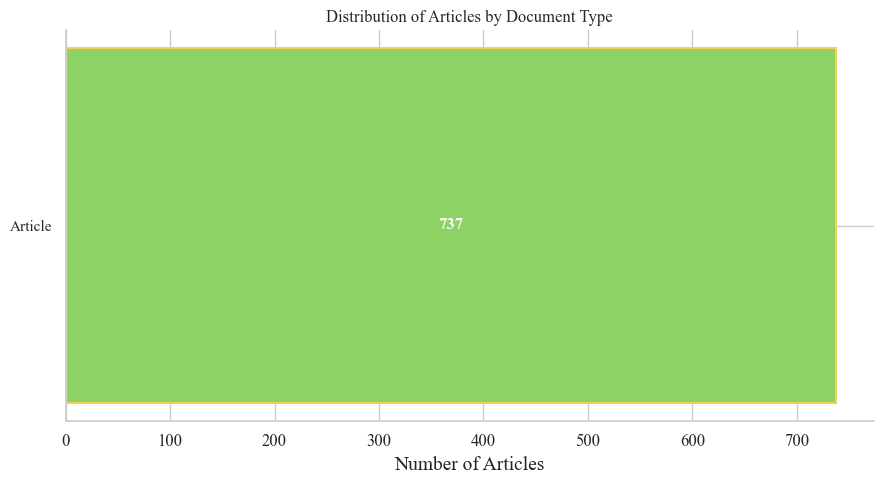

In [4]:
if "document_type" in df.columns:
    doc_types = df["document_type"].apply(
        lambda t: t if t in ["Article", "Conference Paper"] else "Others"
    )
    doc_type_counts = doc_types.value_counts().sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(doc_type_counts.index, doc_type_counts.values,
                    color=MATTE_COLORS["teal"], edgecolor=MATTE_COLORS["gold"], linewidth=1.5)
    for bar in bars:
        width = bar.get_width()
        ax.text(width / 2, bar.get_y() + bar.get_height() / 2, f"{int(width):,}",
                ha="center", va="center", color="white", fontweight="bold")
    ax.set_xlabel("Number of Articles")
    ax.set_title("Distribution of Articles by Document Type")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Column \'document_type\' not found in the dataset -- skipping this chart.")

# 4. Subject Areas

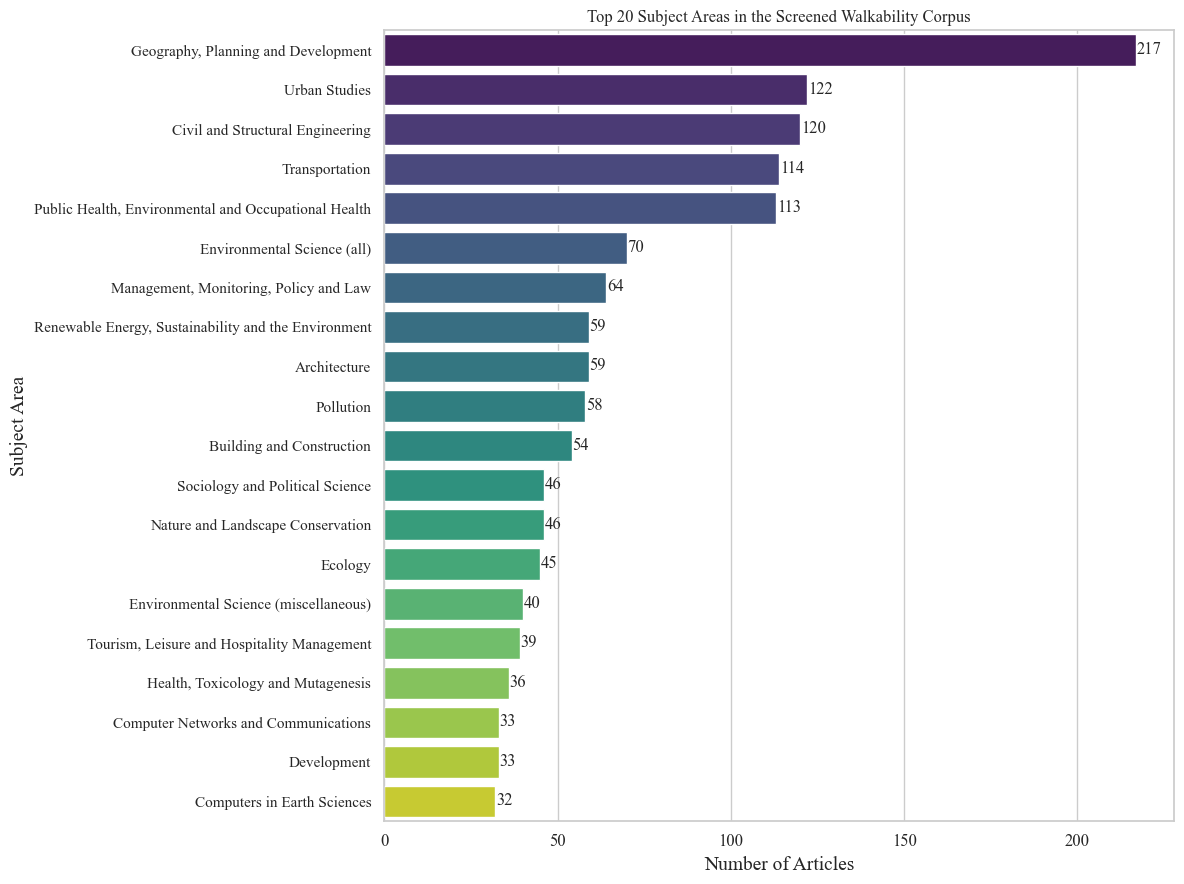

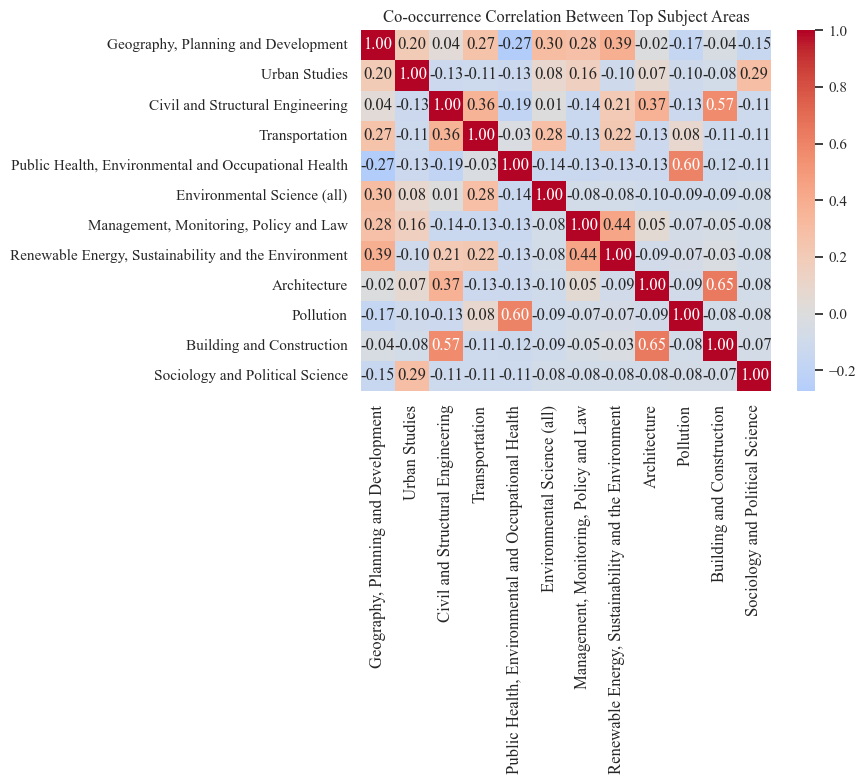

In [5]:
if "subject_areas" in df.columns:
    all_subject_areas = df["subject_areas"].dropna().explode()
    subject_counts = all_subject_areas.value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 9))
    sns.barplot(x=subject_counts.values, y=subject_counts.index, hue=subject_counts.index,
                palette="viridis", legend=False, ax=ax)
    ax.set_title("Top 20 Subject Areas in the Screened Walkability Corpus")
    ax.set_xlabel("Number of Articles")
    ax.set_ylabel("Subject Area")
    for i, v in enumerate(subject_counts.values):
        ax.text(v + 0.2, i, str(v), va="center")
    plt.tight_layout()
    plt.show()

    top_subjects = subject_counts.head(12).index
    presence = pd.DataFrame({
        subject: df["subject_areas"].apply(lambda areas: subject in areas if isinstance(areas, list) else False)
        for subject in top_subjects
    })
    subject_corr = presence.corr()

    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(subject_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Co-occurrence Correlation Between Top Subject Areas")
    plt.tight_layout()
    plt.show()
else:
    print("Column \'subject_areas\' not found in the dataset -- skipping this chart.")

# 5. Sensing Modality Distribution

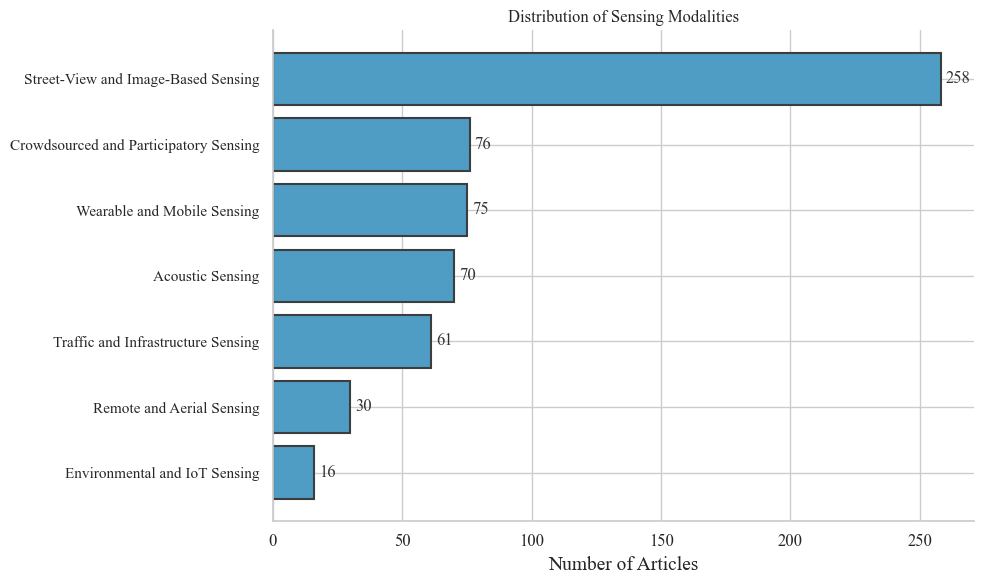

In [6]:
sensor_counts = Counter()
for categories in df["macro_sensor_types"]:
    sensor_counts.update(categories)

df_sensors = pd.DataFrame(sensor_counts.most_common(), columns=["Sensor Category", "Count"])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_sensors["Sensor Category"][::-1], df_sensors["Count"][::-1],
                color=MATTE_COLORS["blue"], edgecolor=MATTE_COLORS["navy"], linewidth=1.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height() / 2, f"{int(width):,}",
            va="center", color=MATTE_COLORS["text"])
ax.set_xlabel("Number of Articles")
ax.set_title("Distribution of Sensing Modalities")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 6. Walkability Dimension Distribution

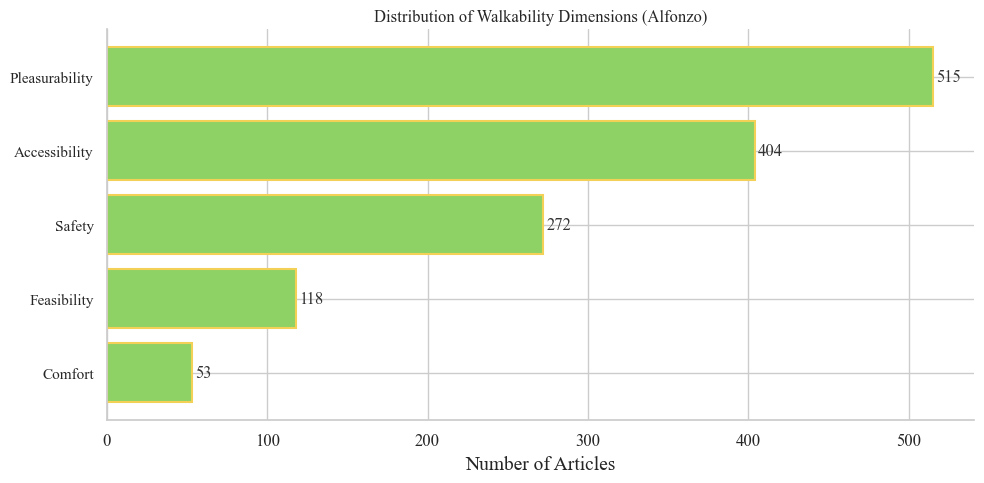

In [7]:
dimension_counts = Counter()
for dimensions in df["macro_dimensions"]:
    dimension_counts.update(dimensions)

df_dimensions = pd.DataFrame(dimension_counts.most_common(), columns=["Dimension", "Count"])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_dimensions["Dimension"][::-1], df_dimensions["Count"][::-1],
                color=MATTE_COLORS["teal"], edgecolor=MATTE_COLORS["gold"], linewidth=1.5)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height() / 2, f"{int(width):,}",
            va="center", color=MATTE_COLORS["text"])
ax.set_xlabel("Number of Articles")
ax.set_title("Distribution of Walkability Dimensions (Alfonzo)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# 7. Label Combination Frequency

C:\Users\vinic\AppData\Local\Temp\ipykernel_11960\66510222.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


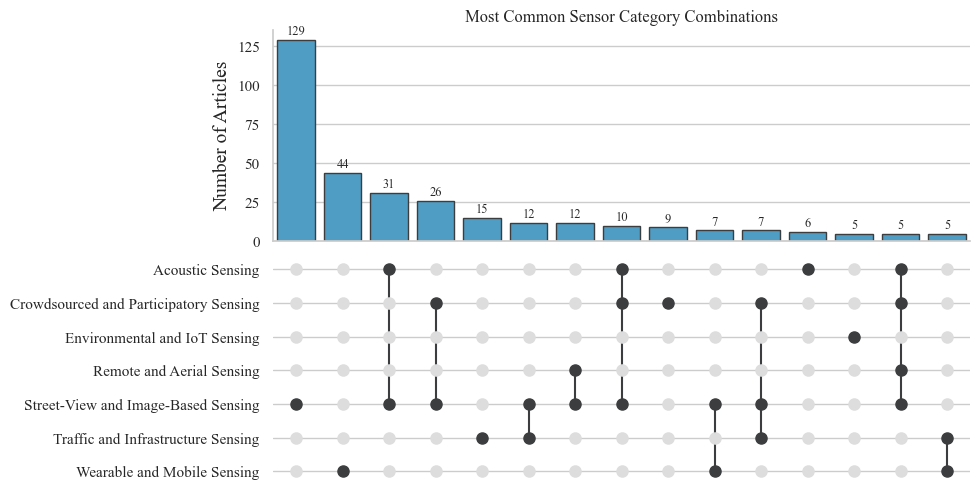

In [8]:
plot_label_combinations(df["macro_sensor_types"], "Most Common Sensor Category Combinations")

C:\Users\vinic\AppData\Local\Temp\ipykernel_11960\66510222.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


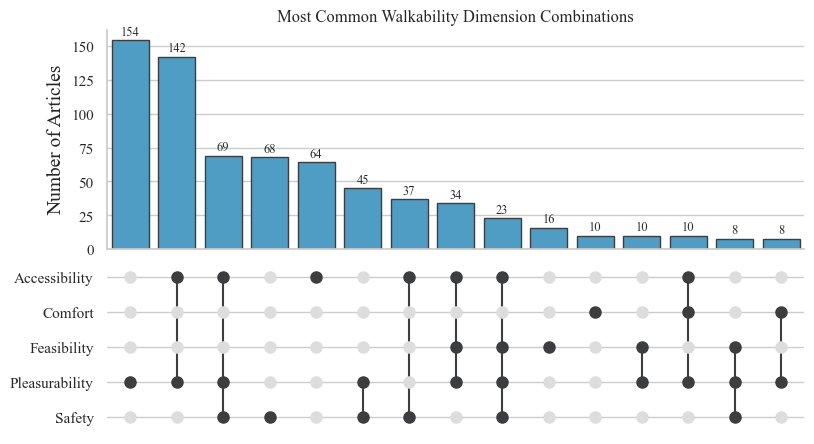

In [9]:
plot_label_combinations(df["macro_dimensions"], "Most Common Walkability Dimension Combinations")

# 8. Sensor x Dimension Cross-Tabulation

In [10]:
pairs = []
for _, row in df.iterrows():
    for sensor in row["macro_sensor_types"]:
        for dimension in row["macro_dimensions"]:
            pairs.append({"sensor": sensor, "dimension": dimension})

pairs_df = pd.DataFrame(pairs)
crosstab_counts = pd.crosstab(pairs_df["sensor"], pairs_df["dimension"])
crosstab_row_pct = pd.crosstab(pairs_df["sensor"], pairs_df["dimension"], normalize="index") * 100

n_with_both = (df["macro_sensor_types"].str.len() > 0) & (df["macro_dimensions"].str.len() > 0)
print(f"Articles contributing to the cross-tabulation (sensor and dimension both assigned): {n_with_both.sum()}")

crosstab_counts

Articles contributing to the cross-tabulation (sensor and dimension both assigned): 366


dimension,Accessibility,Comfort,Feasibility,Pleasurability,Safety
sensor,,,,,
Acoustic Sensing,28,11,2,52,22
Crowdsourced and Participatory Sensing,37,5,6,52,36
Environmental and IoT Sensing,7,8,4,7,7
Remote and Aerial Sensing,14,3,2,26,8
Street-View and Image-Based Sensing,136,13,23,202,114
Traffic and Infrastructure Sensing,36,4,10,36,38
Wearable and Mobile Sensing,34,4,8,63,14


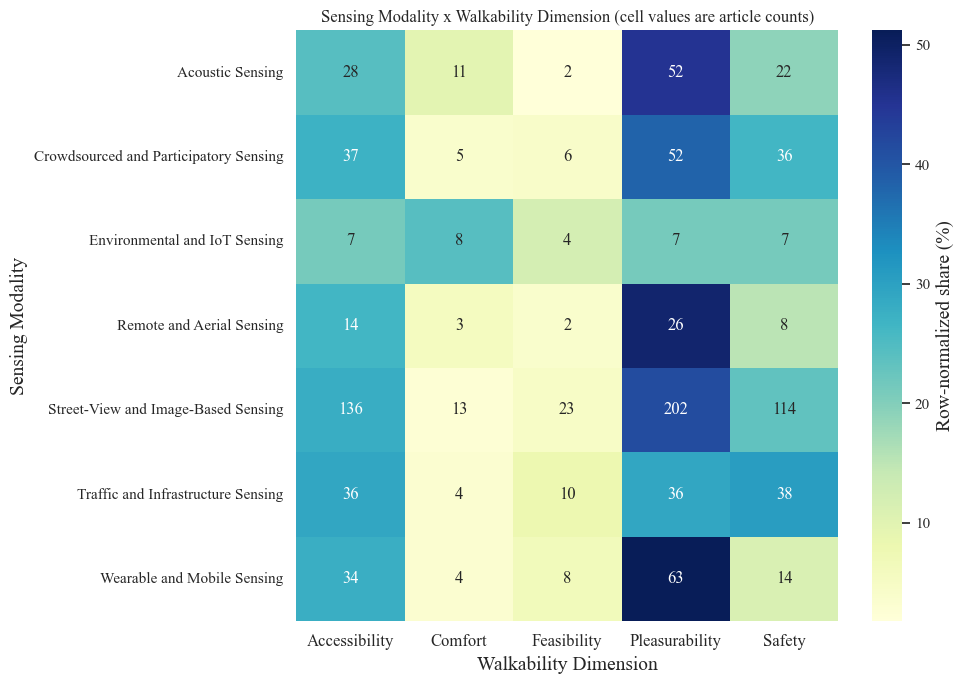

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(crosstab_row_pct, annot=crosstab_counts, fmt="d", cmap="YlGnBu",
            cbar_kws={"label": "Row-normalized share (%)"}, ax=ax)
ax.set_title("Sensing Modality x Walkability Dimension (cell values are article counts)")
ax.set_xlabel("Walkability Dimension")
ax.set_ylabel("Sensing Modality")
plt.tight_layout()
plt.show()

# 9. Statistical Association: Chi-Square Test and Standardized Residuals

Chi-square statistic: 75.80
Degrees of freedom: 24
p-value: 2.8e-07


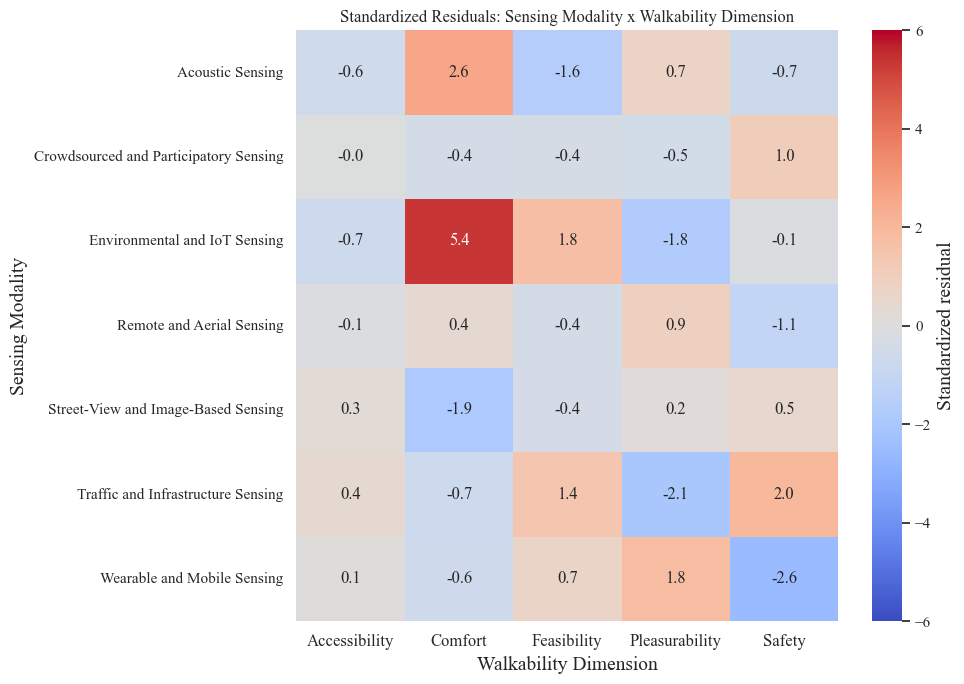


Cells with |standardized residual| > 2 (association stronger than expected under independence):
  - Acoustic Sensing x Comfort: 2.58 (over-represented)
  - Environmental and IoT Sensing x Comfort: 5.37 (over-represented)
  - Traffic and Infrastructure Sensing x Pleasurability: -2.06 (under-represented)
  - Wearable and Mobile Sensing x Safety: -2.56 (under-represented)


In [12]:
chi2, p_value, dof, expected = chi2_contingency(crosstab_counts)
expected_df = pd.DataFrame(expected, index=crosstab_counts.index, columns=crosstab_counts.columns)
standardized_residuals = (crosstab_counts - expected_df) / np.sqrt(expected_df)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4g}")

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(standardized_residuals, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            vmin=-6, vmax=6, cbar_kws={"label": "Standardized residual"}, ax=ax)
ax.set_title("Standardized Residuals: Sensing Modality x Walkability Dimension")
ax.set_xlabel("Walkability Dimension")
ax.set_ylabel("Sensing Modality")
plt.tight_layout()
plt.show()

print("\nCells with |standardized residual| > 2 (association stronger than expected under independence):")
for sensor in standardized_residuals.index:
    for dimension in standardized_residuals.columns:
        value = standardized_residuals.loc[sensor, dimension]
        if abs(value) > 2:
            direction = "over-represented" if value > 0 else "under-represented"
            print(f"  - {sensor} x {dimension}: {value:.2f} ({direction})")

# 10. Article-Level Archetypes: Hierarchical Clustering
Categories are weighted by inverse document frequency before computing distance, so ubiquitous categories (e.g. Street-View, present in most articles) do not dominate the clustering and rarer, more distinguishing combinations can separate out.

In [13]:
archetype_df = df[(df["macro_sensor_types"].str.len() > 0) & (df["macro_dimensions"].str.len() > 0)].copy()
archetype_df = archetype_df.reset_index(drop=True)

sensor_dummies = pd.get_dummies(archetype_df["macro_sensor_types"].explode()).groupby(level=0).max()
dimension_dummies = pd.get_dummies(archetype_df["macro_dimensions"].explode()).groupby(level=0).max()
feature_matrix = pd.concat([sensor_dummies, dimension_dummies], axis=1).fillna(0).astype(int)

print(f"Articles included in archetype analysis: {len(feature_matrix)}")
print(f"Feature dimensions (sensor categories + walkability dimensions): {feature_matrix.shape[1]}")

# Inverse document frequency per category, so common categories contribute less to
# distance than rare, more discriminating ones.
n_articles = len(feature_matrix)
category_frequency = feature_matrix.sum(axis=0)
idf_weights = np.log((1 + n_articles) / (1 + category_frequency)) + 1
weighted_matrix = feature_matrix.values * idf_weights.values

distance_matrix = cosine_distances(weighted_matrix)
condensed_distance = squareform(distance_matrix, checks=False)
linkage_matrix = linkage(condensed_distance, method="average")

Articles included in archetype analysis: 366
Feature dimensions (sensor categories + walkability dimensions): 12


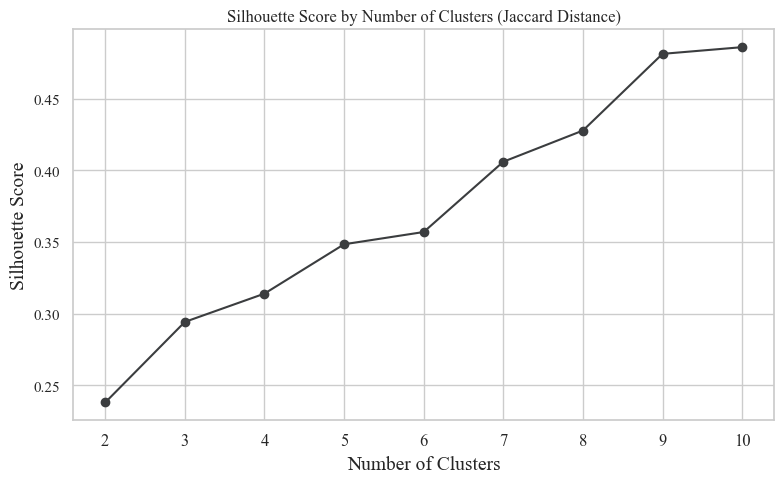

Selected number of clusters: 10 (silhouette score: 0.486)


In [14]:
silhouette_scores = {}
for k in range(2, 11):
    cluster_labels = fcluster(linkage_matrix, t=k, criterion="maxclust")
    if len(set(cluster_labels)) > 1:
        silhouette_scores[k] = silhouette_score(distance_matrix, cluster_labels, metric="precomputed")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), "o-", color=MATTE_COLORS["navy"])
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by Number of Clusters (Jaccard Distance)")
plt.tight_layout()
plt.show()

optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Selected number of clusters: {optimal_k} (silhouette score: {silhouette_scores[optimal_k]:.3f})")

cluster_labels = fcluster(linkage_matrix, t=optimal_k, criterion="maxclust") - 1
archetype_df["cluster"] = cluster_labels

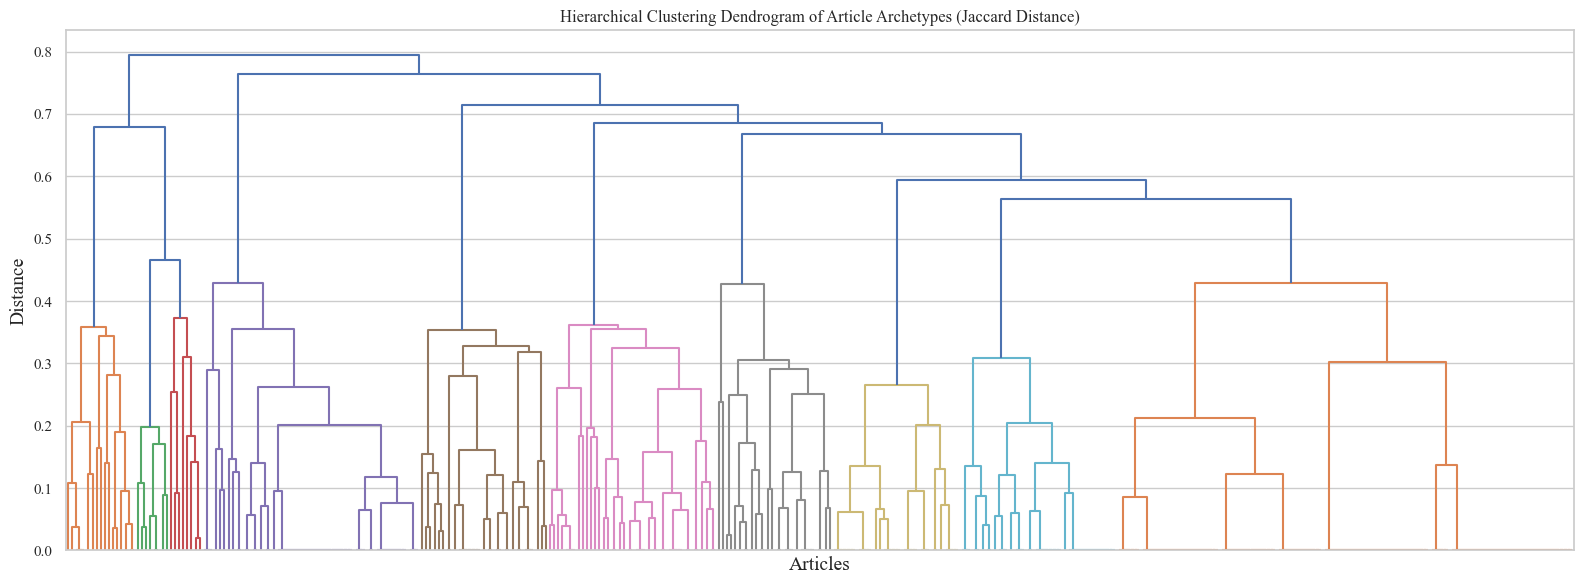

In [15]:
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linkage_matrix, ax=ax, no_labels=True, color_threshold=linkage_matrix[-(optimal_k - 1), 2])
ax.set_title("Hierarchical Clustering Dendrogram of Article Archetypes (Jaccard Distance)")
ax.set_xlabel("Articles")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

# 11. MDS Projection of Article Archetypes

C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


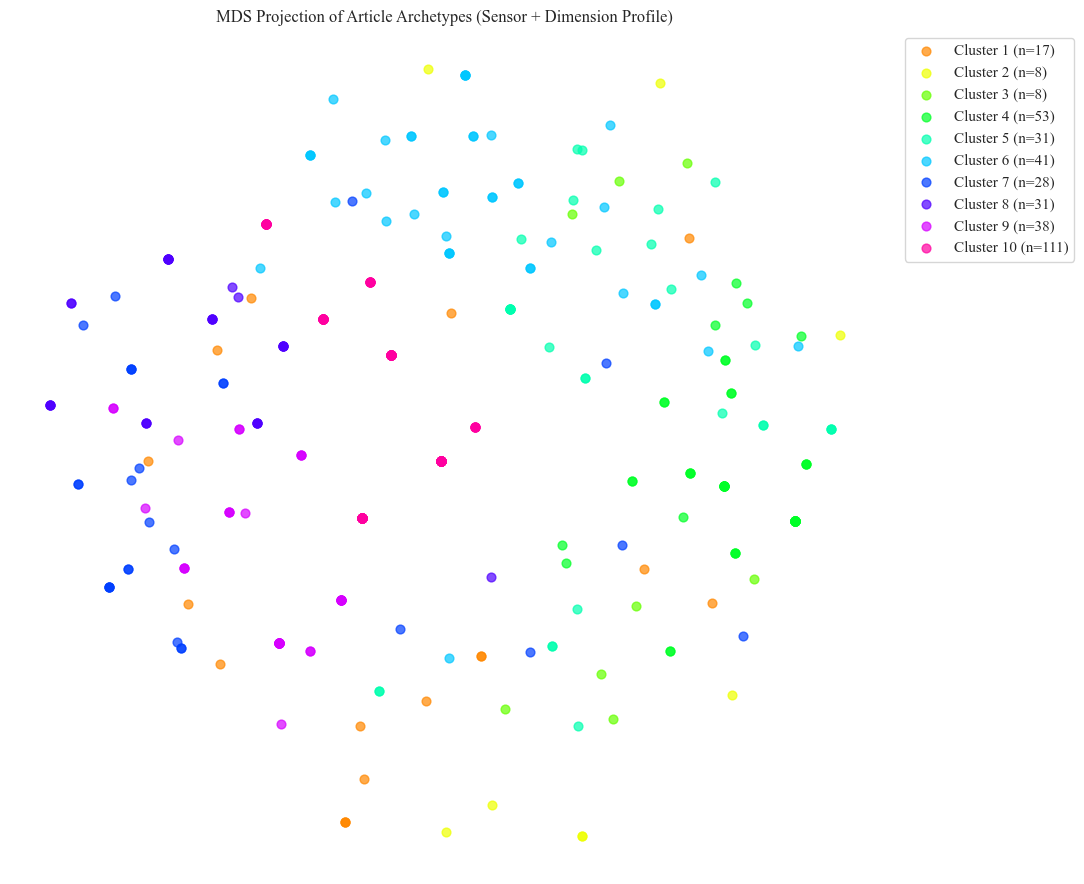

In [16]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress="auto")
positions = mds.fit_transform(distance_matrix)

palette = sns.color_palette("hsv", optimal_k)

fig, ax = plt.subplots(figsize=(11, 9))
for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax.scatter(positions[mask, 0], positions[mask, 1], s=40, alpha=0.7,
               color=palette[cluster_id], label=f"Cluster {cluster_id + 1} (n={mask.sum()})")

ax.set_title("MDS Projection of Article Archetypes (Sensor + Dimension Profile)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.axis("off")
plt.tight_layout()
plt.show()

# 12. Cluster Composition Summary

In [17]:
summary_rows = []
for cluster_id in range(optimal_k):
    cluster_data = archetype_df[archetype_df["cluster"] == cluster_id]

    sensor_counts_cluster = Counter()
    for categories in cluster_data["macro_sensor_types"]:
        sensor_counts_cluster.update(categories)

    dimension_counts_cluster = Counter()
    for dimensions in cluster_data["macro_dimensions"]:
        dimension_counts_cluster.update(dimensions)

    top_sensor = sensor_counts_cluster.most_common(1)[0][0] if sensor_counts_cluster else "-"
    top_dimension = dimension_counts_cluster.most_common(1)[0][0] if dimension_counts_cluster else "-"

    summary_rows.append({
        "Cluster": cluster_id + 1,
        "Size": len(cluster_data),
        "Dominant Sensor": top_sensor,
        "Dominant Dimension": top_dimension,
        "Top 3 Sensors": ", ".join(s for s, _ in sensor_counts_cluster.most_common(3)),
        "Top 3 Dimensions": ", ".join(d for d, _ in dimension_counts_cluster.most_common(3)),
    })

cluster_summary = pd.DataFrame(summary_rows).set_index("Cluster")
cluster_summary

,Size,Dominant Sensor,Dominant Dimension,Top 3 Sensors,Top 3 Dimensions
Cluster,,,,,
1,17,Street-View and Image-Based Sensing,Comfort,"Street-View and Image-Based Sensing, Acoustic Sensing, Crowdsourced and Participatory Sensing","Comfort, Accessibility, Pleasurability"
2,8,Environmental and IoT Sensing,Comfort,"Environmental and IoT Sensing, Traffic and Infrastructure Sensing, Acoustic Sensing","Comfort, Safety, Pleasurability"
3,8,Environmental and IoT Sensing,Accessibility,"Environmental and IoT Sensing, Traffic and Infrastructure Sensing, Crowdsourced and Participator...","Accessibility, Safety, Pleasurability"
4,53,Wearable and Mobile Sensing,Pleasurability,"Wearable and Mobile Sensing, Street-View and Image-Based Sensing, Crowdsourced and Participatory...","Pleasurability, Accessibility, Safety"
5,31,Street-View and Image-Based Sensing,Feasibility,"Street-View and Image-Based Sensing, Wearable and Mobile Sensing, Traffic and Infrastructure Sen...","Feasibility, Pleasurability, Accessibility"
6,41,Traffic and Infrastructure Sensing,Safety,"Traffic and Infrastructure Sensing, Street-View and Image-Based Sensing, Crowdsourced and Partic...","Safety, Pleasurability, Accessibility"
7,28,Remote and Aerial Sensing,Pleasurability,"Remote and Aerial Sensing, Street-View and Image-Based Sensing, Crowdsourced and Participatory S...","Pleasurability, Accessibility, Safety"
8,31,Crowdsourced and Participatory Sensing,Pleasurability,"Crowdsourced and Participatory Sensing, Street-View and Image-Based Sensing","Pleasurability, Safety, Accessibility"
9,38,Acoustic Sensing,Pleasurability,"Acoustic Sensing, Street-View and Image-Based Sensing, Crowdsourced and Participatory Sensing","Pleasurability, Accessibility, Safety"
